In [1]:
import re

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm

from tqdm.auto import tqdm as tqdm_auto
from tqdm.notebook import tqdm

In [2]:
d1 = pd.read_csv("../../data/lib2/raw/UTR3_sequence_counts_06_04_24.tsv", sep="\t", index_col=0, header=[0, 1, 2])
d1.index.name = "seq"
d1.columns.names = ["cell_type", "replicate", "bin"]
d1

cell_type                                             c17                  \
replicate                                               1                   
bin                                                     1       2       3   
seq                                                                         
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAA...   2993    9189   16908   
CCCAGCCCCCGTGCACTAATGCGGATGCACCTCAAAAGCTTCCAACC...    171     251    2294   
GGCTGTGGAGAAGGTTCTTGGCCCGTTGGACTCACACAGACCCTGTA...  39369   65197   53495   
GCAGAAGTGAATAGTCCAATTTCTGTTTGGCACCCATCTGGATTTTC...      6     162     237   
TAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCC...   3024    9176   16859   
...                                                   ...     ...     ...   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...  20319   33279   57624   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...  53565   40111   18931   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...  10440    6334   14783   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...  73496  122181  109466   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...   9355   14393   10030   

cell_type                                                                 \
replicate                                                      2           
bin                                                     4      1       2   
seq                                                                        
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAA...  15420   1721    7232   
CCCAGCCCCCGTGCACTAATGCGGATGCACCTCAAAAGCTTCCAACC...   7456     51      59   
GGCTGTGGAGAAGGTTCTTGGCCCGTTGGACTCACACAGACCCTGTA...  29133  23296   59108   
GCAGAAGTGAATAGTCCAATTTCTGTTTGGCACCCATCTGGATTTTC...    115      9      49   
TAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCC...  20182   1819    7072   
...                                                   ...    ...     ...   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...  74364  16371   20569   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...   5460  41029   40692   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...  38814  10013    2674   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...  61719  46857  114904   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...   3640   6060   17466   

cell_type                                                             c2  \
replicate                                                              1   
bin                                                      3      4      1   
seq                                                                        
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAA...   17296  12774   4556   
CCCAGCCCCCGTGCACTAATGCGGATGCACCTCAAAAGCTTCCAACC...     715   6445   1380   
GGCTGTGGAGAAGGTTCTTGGCCCGTTGGACTCACACAGACCCTGTA...   58421  23901  23949   
GCAGAAGTGAATAGTCCAATTTCTGTTTGGCACCCATCTGGATTTTC...     104     14    492   
TAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCC...   16675  18868   4898   
...                                                    ...    ...    ...   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...   59996  71020  21407   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...   15017   4006  40972   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...    6626  40980   1862   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...  126737  51962  64989   
CCATCCGCCATTCCGACTGCTAAAAGCGAATGTAGTCAGGCCCCTTT...    9415   2937  10567   

cell_type                                                  ...    c1         \
replicate                                                  ...     1          
bin                                                     2  ...     3      4   
seq                                                        ...                
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAA...   9279  ...   325   2405   
CCCAGCCCCCGTGCACTAATGCGGATGCACCTCAAAAGCTTCCAACC...   2018  ...   178   1003   
GGCTGTGGAGAAGGTTCTTGGCCCGTTGGACTCACACAGACCCTGTA...  38662  ...  1165  10562   
GCAGAAGTG

In [3]:
d1.isna().any(axis=1).value_counts()

False    12836
Name: count, dtype: int64

## Filtering

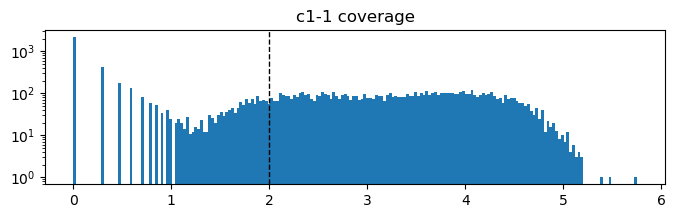

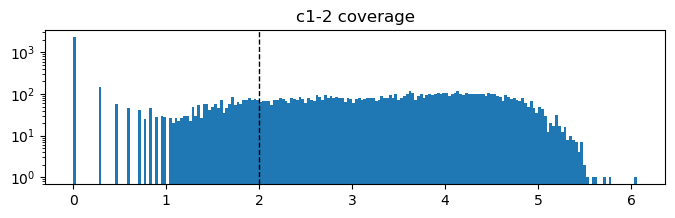

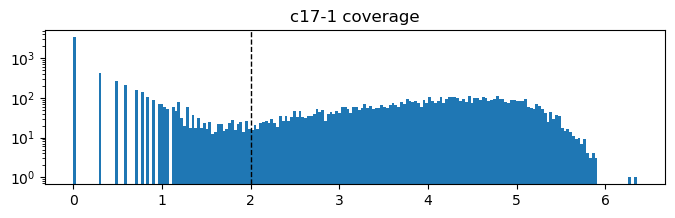

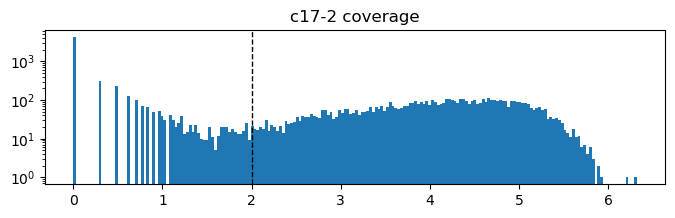

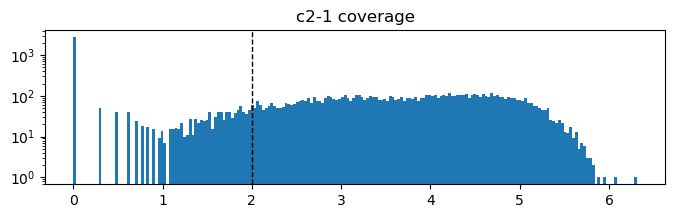

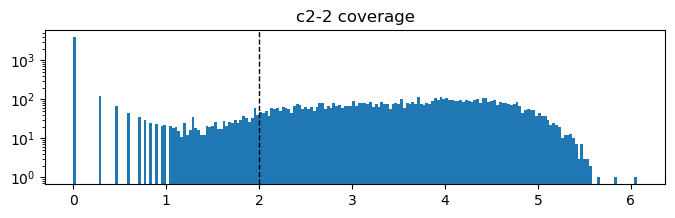

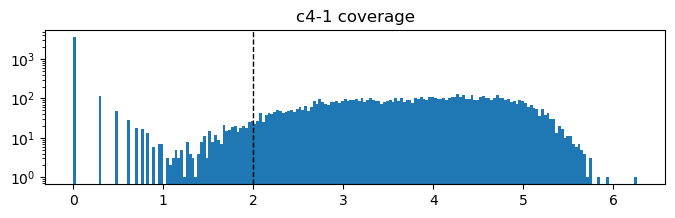

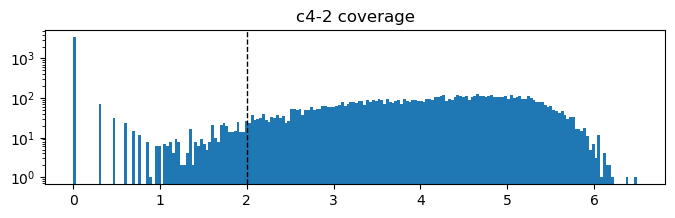

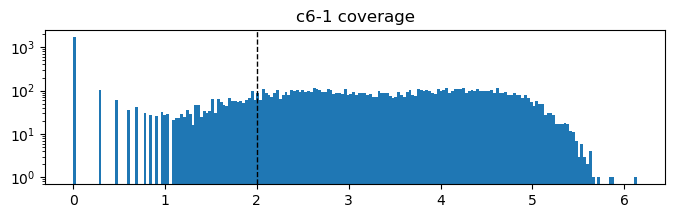

In [4]:
for ct in np.unique(d1.columns.get_level_values(0)):
    d2 = d1.loc[:, pd.IndexSlice[[ct], :, :]]
    for replicate in np.unique(d2.columns.get_level_values(1)):
        d3 = d2.loc[:, pd.IndexSlice[:, [replicate], :]]
        plt.figure(figsize=(8, 2))
        plt.hist(np.log10(1 + d3.sum(axis=1)), bins=200)
        plt.yscale("log")
        plt.title(f"{ct}-{replicate} coverage")
        plt.axvline(np.log10(100), color="k", ls="--", lw=1)
        #plt.axvline(np.log10(100000), color="r", ls="--", lw=1)
        plt.show()

In [5]:
d1_subdfs = []
for ct in np.unique(d1.columns.get_level_values(0)):
    d2 = d1.loc[:, pd.IndexSlice[[ct], :, :]]
    for replicate in np.unique(d2.columns.get_level_values(1)):
        d3 = d2.loc[:, pd.IndexSlice[:, [replicate], :]]
        filter_min = d3.min(axis=1) >= 10
        filter_sum = d3.apply(sorted, axis=1).str[2] >= 50  # second largest >= 50
        # filter_sum = d3.sum(axis=1) >= 100
        filter_max = d3.max(axis=1) < 1_000_000
        d3_filtered = d3[filter_sum & filter_min & filter_max]
        d1_subdfs.append(d3_filtered)
d1_filtered = pd.concat(d1_subdfs, axis=1)

In [6]:
# replacing data
d1_orig = d1
d1 = d1_filtered.fillna(0).astype(np.int32)

## Loading fits

In [7]:
fits = pd.read_csv("fit_results_utr3.csv")
fits

,cell_type,replicate,bin,psi,p,n
0,c17,1,1,0.826212,0.000017,0.135082
1,c17,1,2,0.891915,0.000018,0.123465
2,c17,1,3,0.803938,0.000020,0.163205
3,c17,1,4,0.885476,0.000018,0.127331
4,c17,2,1,0.709420,0.000020,0.169014
5,c17,2,2,0.686368,0.000022,0.205404
6,c17,2,3,0.680665,0.000021,0.204787
7,c17,2,4,0.770945,0.000019,0.148974
8,c2,1,1,0.777265,0.000040,0.243465
9,c2,1,2,0.783594,0.000034,0.263308


In [8]:
reference_fit_id = ('c2', 1, 1)
reference_fit_id

('c2', 1, 1)

In [9]:
reference_fit_params = fits.set_index(["cell_type", "replicate", "bin"]).loc[reference_fit_id].to_dict()
reference_fit_params

{'psi': 0.7772645776042084,
 'p': 4.043607821133281e-05,
 'n': 0.2434652219993212}

In [10]:
# reference_fit_params = {
#     'psi': 0.9845783770172688,
#     'p': 0.0021913046817362,
#     'n': 1.631848757785423
# }

In [11]:
def get_reference_rv(psi, p, n):
    mixture_dist = pm.ZeroInflatedNegativeBinomial.dist(psi=psi, p=p, n=n)
    return mixture_dist

In [12]:
reference_rv = get_reference_rv(**reference_fit_params)

Checking the maximal theoretical value (it's unlikely that we are going to exceed it)

In [13]:
max_theoretical_value = d1_orig.max(axis=None)
max_theoretical_value

1486942

In [14]:
from scipy.spatial import KDTree


def get_discrete_icdf(rv, min_value=0, max_value=100_000):
    if min_value != 0:
        raise NotImplementedError
    logcdf = pm.logcdf(rv, np.arange(0, max_value + 1)).eval()
    cdf = np.exp(logcdf)
    round_tree = KDTree(cdf[:, np.newaxis], leafsize=10)

    def icdf(q: np.array):
        q = np.asarray(q)
        norm_vals = round_tree.query(q[:, np.newaxis], k=1)[1]
        # indices returned by the query are in fact the RV values as well
        return norm_vals

    return icdf

In [15]:
d1_normalized = d1.copy()

for (cell_type_id, replicate_id), fits_grp in tqdm(fits.groupby(by=["cell_type", "replicate"])):
    for i, lib_fit in fits_grp.iterrows():
        # Fitting library
        lib_key = (lib_fit["cell_type"], str(lib_fit["replicate"]), str(lib_fit["bin"]))
        lib = d1[lib_key].values
        libmax = lib.max()
        nanfilter = lib == 0
        lib_fit_params = lib_fit.iloc[3:].to_dict()

        # Calculating CDF
        lib_rv = get_reference_rv(**lib_fit_params)
        lib_logcdf = logcdf = pm.logcdf(lib_rv, np.arange(0, libmax + 1)).eval()
        lib_cdf = np.exp(lib_logcdf)
        lib_q = lib_cdf[lib]  # Since library starts at 0, cdf array is the inverse quantile function

        # Calculating quantiles
        reference_icdf_func = get_discrete_icdf(reference_rv, max_value=max_theoretical_value)
        lib_norm = reference_icdf_func(lib_q)

        # Normalizing CPMs
        lib_norm = lib_norm + 1
        lib_norm[nanfilter] = 0
        # # Notice the pseudocount
        lib_norm_cpm = lib_norm / lib_norm.sum() * 1_000_000
        d1_normalized[lib_key] = lib_norm

  0%|          | 0/9 [00:00<?, ?it/s]

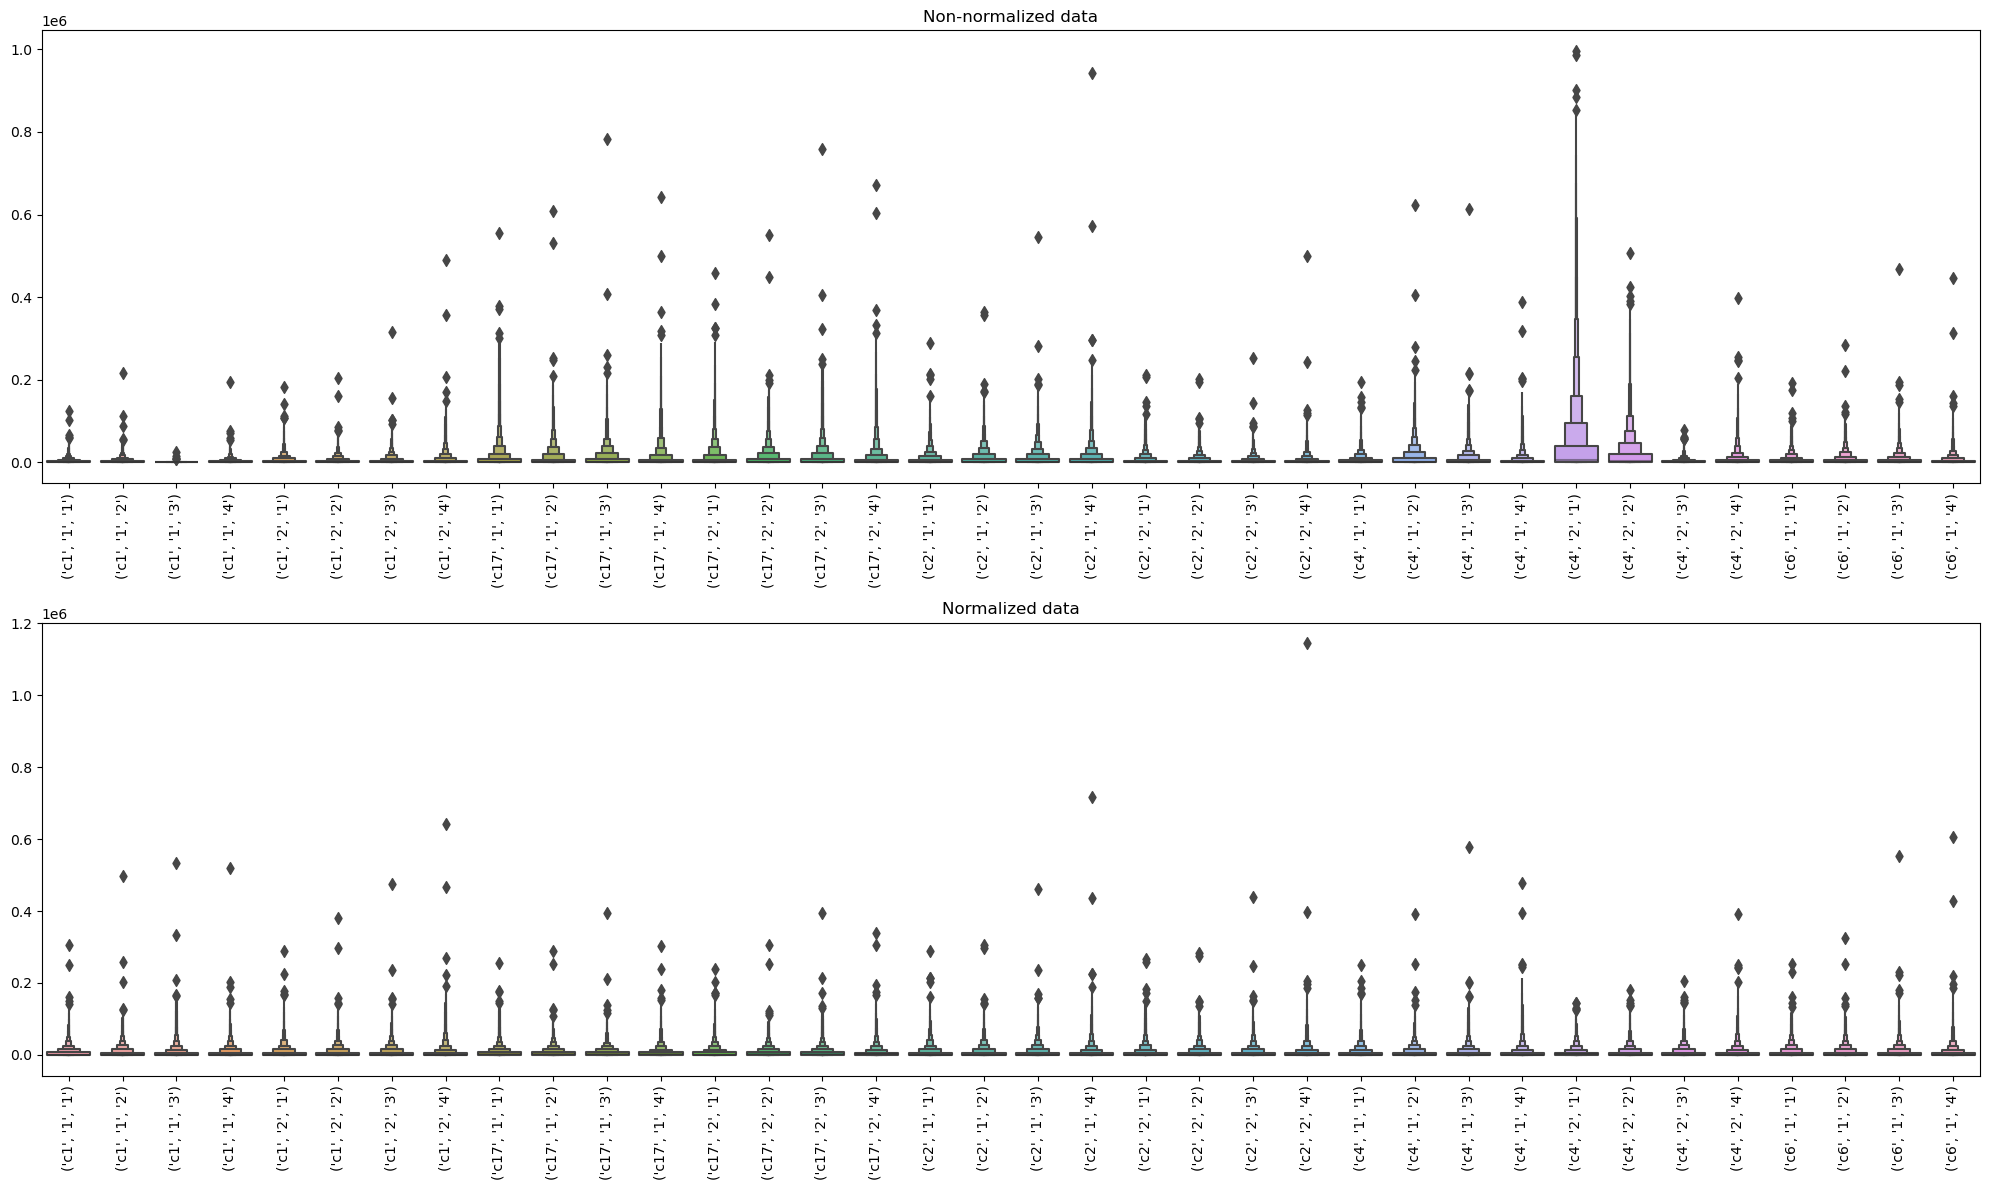

In [16]:
plt.figure(figsize=(20, 12))

plt.subplot(2, 1, 1)
sns.boxenplot(d1)
plt.xticks(rotation=90)
plt.title("Non-normalized data")

plt.subplot(2, 1, 2)
sns.boxenplot(d1_normalized)
plt.xticks(rotation=90)
plt.title("Normalized data")

plt.tight_layout()
plt.show()

## Preprocessing

In [17]:
d1_filtered = d1_normalized.copy()
d1_filtered.index.name = "seq"
d1_filtered

cell_type                                              c1                \
replicate                                               1                 
bin                                                     1      2      3   
seq                                                                       
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAA...   4132   6575   7155   
CCCAGCCCCCGTGCACTAATGCGGATGCACCTCAAAAGCTTCCAACC...   2061   1631   3839   
GGCTGTGGAGAAGGTTCTTGGCCCGTTGGACTCACACAGACCCTGTA...  20885  25411  25601   
TAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCC...   5029   7503   9101   
TGCAAGTAAAAATCCGCGCTGGTATAAGCCATTTCTGTGCCGCTTTT...   5660   5514  23413   
...                                                   ...    ...    ...   
TTTGGTGCTAGTAGGGGAAGGGGGGAGGGAGAAGGGGGACAGGCTTG...      0      0      0   
TTTGTAACCTAGTATATTAATAAAAATTGATAATTGTGTTGTAAAAA...      0      0      0   
TTTGTATCTTCAATTTAAATCACTTAGCTCTACCTGTTTATTATGAT...      0      0      0   
TTTTAATAACCTAGTGGGGTTTATTCTTGTGAATTTTTGCCTTTAAA...      0      0      0   
TTTTTCAGGGTGTTTATAGCATCATGACATTAAAATGTAATCAGTAG...      0      0      0   

cell_type                                                                \
replicate                                                      2          
bin                                                     4      1      2   
seq                                                                       
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAA...   6171   3072   3996   
CCCAGCCCCCGTGCACTAATGCGGATGCACCTCAAAAGCTTCCAACC...   2478   1329   3107   
GGCTGTGGAGAAGGTTCTTGGCCCGTTGGACTCACACAGACCCTGTA...  27946  16666  27335   
TAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCC...   7863   4415   4571   
TGCAAGTAAAAATCCGCGCTGGTATAAGCCATTTCTGTGCCGCTTTT...   9595   2636   4190   
...                                                   ...    ...    ...   
TTTGGTGCTAGTAGGGGAAGGGGGGAGGGAGAAGGGGGACAGGCTTG...      0      0      0   
TTTGTAACCTAGTATATTAATAAAAATTGATAATTGTGTTGTAAAAA...      0      0      0   
TTTGTATCTTCAATTTAAATCACTTAGCTCTACCTGTTTATTATGAT...      0      0      0   
TTTTAATAACCTAGTGGGGTTTATTCTTGTGAATTTTTGCCTTTAAA...      0      0      0   
TTTTTCAGGGTGTTTATAGCATCATGACATTAAAATGTAATCAGTAG...      0      0      0   

cell_type                                                           c17  \
replicate                                                             1   
bin                                                     3      4      1   
seq                                                                       
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAA...   5734   5854   4162   
CCCAGCCCCCGTGCACTAATGCGGATGCACCTCAAAAGCTTCCAACC...   5089   7104    655   
GGCTGTGGAGAAGGTTCTTGGCCCGTTGGACTCACACAGACCCTGTA...  30032  18715  25937   
TAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCC...   6381   8048   4191   
TGCAAGTAAAAATCCGCGCTGGTATAAGCCATTTCTGTGCCGCTTTT...   7764  23974   1029   
...                                                   ...    ...    ...   
TTTGGTGCTAGTAGGGGAAGGGGGGAGGGAGAAGGGGGACAGGCTTG...      0      0      0   
TTTGTAACCTAGTATATTAATAAAAATTGATAATTGTGTTGTAAAAA...      0      0      0   
TTTGTATCTTCAATTTAAATCACTTAGCTCTACCTGTTTATTATGAT...      0      0      0   
TTTTAATAACCTAGTGGGGTTTATTCTTGTGAATTTTTGCCTTTAAA...      0      0      0   
TTTTTCAGGGTGTTTATAGCATCATGACATTAAAATGTAATCAGTAG...      0      0      0   

cell_type                                                  ...     c4         \
replicate                                                  ...      1          
bin                                                     2  ...      3      4   
seq                                                        ...                 
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAA...   9237  ...   7345   6972   
CCCAGCCCCCGTGCACTAATGCGGATGCACCTCAAAAGCTTCCAACC...    813  ...   2305   4487   
GGCTGTGGAGAAGGTTCTTGGCCCGTTGGACTCACACAGACCCTGTA...  40211  ...  23342  20038   
TAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCC...   9228  ...

In [18]:
d1_stacked = d1_filtered.stack(level=[0], dropna=False).reset_index()
d1_stacked.columns.name = None
d1_stacked

replicate                                                seq cell_type     1  \
bin                                                                        1   
0          CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...        c1  4132   
1          CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...       c17  4162   
2          CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...        c2  4557   
3          CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...        c4  1478   
4          CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...        c6  4595   
...                                                      ...       ...   ...   
46860      TTTTTCAGGGTGTTTATAGCATCATGACATTAAAATGTAATCAGTA...        c1     0   
46861      TTTTTCAGGGTGTTTATAGCATCATGACATTAAAATGTAATCAGTA...       c17     0   
46862      TTTTTCAGGGTGTTTATAGCATCATGACATTAAAATGTAATCAGTA...        c2     0   
46863      TTTTTCAGGGTGTTTATAGCATCATGACATTAAAATGTAATCAGTA...        c4     0   
46864      TTTTTCAGGGTGTTTATAGCATCATGACATTAAAATGTAATCAGTA...        c6     7   

replicate                           2                            
bin           2      3      4       1       2        3        4  
0          6575   7155   6171  3072.0  3996.0   5734.0   5854.0  
1          9237  12816  13111  2940.0  6584.0  12700.0  11879.0  
2          6880   6743   8976  5501.0  8183.0   7361.0   8652.0  
3          5159   7345   6972  1454.0  3949.0   5890.0   5306.0  
4          4931   6968   6942     NaN     NaN      NaN      NaN  
...         ...    ...    ...     ...     ...      ...      ...  
46860         0      0      0     0.0     0.0      0.0      0.0  
46861         0      0      0     0.0     0.0      0.0      0.0  
46862         0      0      0     0.0     0.0      0.0      0.0  
46863         0      0      0     0.0     0.0      0.0      0.0  
46864        24     13      6     NaN     NaN      NaN      NaN  

[46865 rows x 10 columns]

In [19]:
d1_stacked = d1_stacked.set_index(["seq", "cell_type"]).stack(level=0).reset_index()

In [20]:
d1_split = d1_stacked.set_index("seq")
d1_split = d1_split[d1_split[["1", "2", "3", "4"]].sum(axis=1) != 0]
d1_split

bin,cell_type,replicate,1,2,3,4
seq,,,,,,
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAAGGATCCACACACATCCTCACCCCACAGAAACTGCTGGACACACTGAAGAAACTGAATAAAACAGATGAAGAAATAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCCCACAGCGCTCCGCAGCTTCCCACCACCGCCCGCCTCAGTTCCTTTGCGTCTGTTGCCTCCCCAGCCCTGCACG,c1,1,4132.0,6575.0,7155.0,6171.0
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAAGGATCCACACACATCCTCACCCCACAGAAACTGCTGGACACACTGAAGAAACTGAATAAAACAGATGAAGAAATAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCCCACAGCGCTCCGCAGCTTCCCACCACCGCCCGCCTCAGTTCCTTTGCGTCTGTTGCCTCCCCAGCCCTGCACG,c1,2,3072.0,3996.0,5734.0,5854.0
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAAGGATCCACACACATCCTCACCCCACAGAAACTGCTGGACACACTGAAGAAACTGAATAAAACAGATGAAGAAATAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCCCACAGCGCTCCGCAGCTTCCCACCACCGCCCGCCTCAGTTCCTTTGCGTCTGTTGCCTCCCCAGCCCTGCACG,c17,1,4162.0,9237.0,12816.0,13111.0
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAAGGATCCACACACATCCTCACCCCACAGAAACTGCTGGACACACTGAAGAAACTGAATAAAACAGATGAAGAAATAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCCCACAGCGCTCCGCAGCTTCCCACCACCGCCCGCCTCAGTTCCTTTGCGTCTGTTGCCTCCCCAGCCCTGCACG,c17,2,2940.0,6584.0,12700.0,11879.0
CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTAAGGATCCACACACATCCTCACCCCACAGAAACTGCTGGACACACTGAAGAAACTGAATAAAACAGATGAAGAAATAAGCAGTTAAAAAAATAAGTCGCCCCTCCAAAACACGCCCCCATCCCACAGCGCTCCGCAGCTTCCCACCACCGCCCGCCTCAGTTCCTTTGCGTCTGTTGCCTCCCCAGCCCTGCACG,c2,1,4557.0,6880.0,6743.0,8976.0
...,...,...,...,...,...,...
TTTGGTGCTAGTAGGGGAAGGGGGGAGGGAGAAGGGGGACAGGCTTGCAAGTCCAATGCCACAGAGGTGCTCCAGCCACTTTTTTTTTTTTTTTTTTTTTTTAAGATAGTATGTAGACCGGAAACTTGTTTTGTTTAGGTCAGAATTCAAATTTTTAAAGGTGCTTTTTTATGTGTGAGCAACAAGAGAAAGAACAACATGGCACAACCCAACAAACAGTGCAATCAAATGTTTTTTTTT,c6,1,43.0,20.0,21.0,32.0
TTTGTAACCTAGTATATTAATAAAAATTGATAATTGTGTTGTAAAAAAAAAAAAAAAAATTCATTTCTTTTTTTTCTCACCTTTATGTTTAAGTCAGATTTGCTTAAAACGAAGGTCTGCTTTTTGGAAGTGGTGGTCTGAAGGTAACCTGATTTTCAGTTTCTGCATCTCAAAGGTGTAATAAAAGGATGGTTTATATGGTTGGGGTTGATCAATTGAGTGCCAGAGTTTGTTTCTGAG,c6,1,6.0,2.0,35.0,52.0
TTTGTATCTTCAATTTAAATCACTTAGCTCTACCTGTTTATTATGATGACTCCCTAGATGCACATGTCTACCTGCAGCCAAGTCTTCTTAAACCATTAAGTGTGATCAAGTACATTTTAAAAGCATTTATGGTCCTCTCTTGTTCCAGCCAAGTTTCCATAAAATTTGTGTGTGATTCTCCCCAAAATGCTAGCCACTTTACATTCATGATATTAGTTTCAGAATGGCACTGGGCTAGTG,c6,1,14.0,145.0,73.0,98.0


In [21]:
d1_split.to_csv("../../data/lib2/UTR3_zinb_norm_2024-06-04.csv")